In [10]:
!pip install yfinance
import yfinance as yf
import pandas as pd

In [11]:
# Select Apple
apple = yf.Ticker("AAPL")

# Pull the three statements
income_stmt = apple.financials
balance_sheet = apple.balance_sheet
cash_flow = apple.cashflow

# Clean the data: We only want the last 3 years
# and we want to flip the table so dates are on the left
is_df = income_stmt.T.iloc[::-1]
bs_df = balance_sheet.T.iloc[::-1]
cf_df = cash_flow.T.iloc[::-1]

print("Data successfully pulled!")
is_df[['Total Revenue', 'Net Income']].head() # Show a preview

Data successfully pulled!


,Total Revenue,Net Income
2021-09-30,NaN,NaN
2022-09-30,3.943280e+11,9.980300e+10
2023-09-30,3.832850e+11,9.699500e+10
2024-09-30,3.910350e+11,9.373600e+10
2025-09-30,4.161610e+11,1.120100e+11


In [12]:
# Calculate historical growth rate
revenue = is_df['Total Revenue']
historical_growth = revenue.pct_change().mean()

# Project 2024 Revenue
projected_growth = 0.05 # We assume 5% for our model
last_revenue = revenue.iloc[-1]
revenue_2024 = last_revenue * (1 + projected_growth)

print(f"Historical Average Growth: {historical_growth:.2%}")
print(f"Projected 2024 Revenue: ${revenue_2024:,.0f}")

Historical Average Growth: 1.88%
Projected 2024 Revenue: $436,969,050,000


In [13]:
# 1. Get Net Income from the most recent year
net_income_latest = is_df['Net Income'].iloc[-1]

# 2. Get Retained Earnings from the Balance Sheet
retained_earnings_latest = bs_df['Retained Earnings'].iloc[-1]

# 3. Integration: Future Retained Earnings = Current + Net Income
projected_re_2024 = retained_earnings_latest + net_income_latest

print(f"Ending 2023 Retained Earnings: ${retained_earnings_latest:,.0f}")
print(f"Projected 2024 Retained Earnings (Linked): ${projected_re_2024:,.0f}")

Ending 2023 Retained Earnings: $-14,264,000,000
Projected 2024 Retained Earnings (Linked): $97,746,000,000


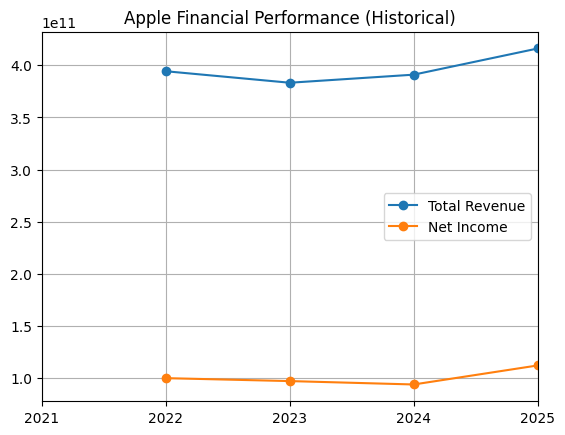

In [14]:
import matplotlib.pyplot as plt

# Create a chart showing Revenue vs Net Income
is_df[['Total Revenue', 'Net Income']].plot(kind='line', marker='o')
plt.title('Apple Financial Performance (Historical)')
plt.grid(True)
plt.show()